See document for the technical difficulties encountered... 

In [11]:
# Standard libraries
import os
import numpy as np
import pandas as pd

# Image handling
from PIL import Image
import matplotlib.pyplot as plt

# HuggingFace / model loading
import torch
# from transformers import AutoProcessor, AutoModelForVision2Seq

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [17]:
# Import Kaggle dataset
!kaggle datasets download -d ahemateja19bec1025/traffic-sign-dataset-classification

Dataset URL: https://www.kaggle.com/datasets/ahemateja19bec1025/traffic-sign-dataset-classification
License(s): CC0-1.0
traffic-sign-dataset-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


Data visualization: want to visualize a few images with their ground truth labels from labels.csv in the dataset

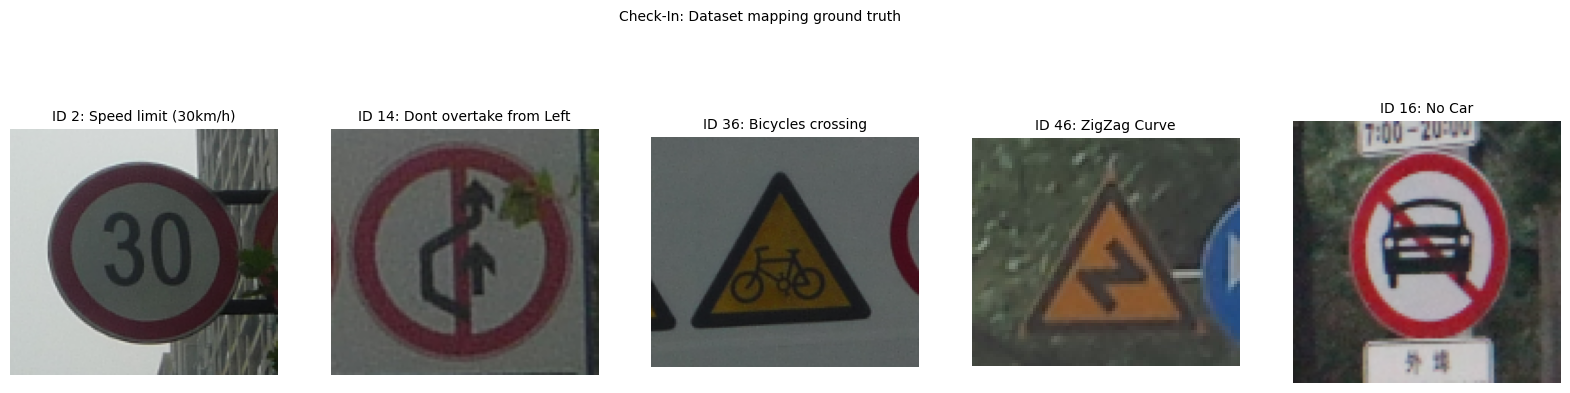

In [ ]:
labels = '/mnt/home/fllin/cv153_final_project/traffic_data/labels.csv'
data = '/mnt/home/fllin/cv153_final_project/traffic_data/traffic_Data/DATA'

#read in the labels data file
df = pd.read_csv(labels)

# sample 5 classes just to see
sample = df.sample(5)

fig, axes = plt.subplots(1,5, figsize=(20, 5))
for i, (idx, row) in enumerate(sample.iterrows()):
    class_id = row['ClassId']
    label_name = row['Name']
    
    class_folder = os.path.join(data, str(class_id))
    
    if os.path.exists(class_folder) and len(os.listdir(class_folder)) > 0:
        first_img = os.listdir(class_folder)[0]
        img_path = os.path.join(class_folder, first_img)
        
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"ID {class_id}: {label_name}", fontsize=10)
        axes[i].axis('off')
    else:
        axes[i].set_title(f"ID {class_id}: Not Found")
        axes[i].axis('off')

plt.suptitle("Check-In: Dataset mapping ground truth", fontsize=10)
plt.show()